In [1]:
import sys
sys.path.append('/work/ConditionalDETR')

In [2]:
import torch
from models import build_model

device = 'cuda:1'

checkpoint = torch.load(f'../output/5kind50000img500epoch/partialV2_resize1/checkpoint0499.pth', map_location='cpu')
args = checkpoint['args']
args.num_classes = 20
model, criterion, postprocessors = build_model(args)
model.to(device)

model_without_ddp = model
model_without_ddp.load_state_dict(checkpoint['model'])
model_without_ddp
model.eval()
criterion.eval()
# checkpoint['model']
args

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth

Namespace(lr=0.0001, lr_backbone=1e-05, batch_size=8, weight_decay=0.0001, epochs=500, lr_drop=40, clip_max_norm=0.1, frozen_weights=None, backbone='resnet50', dilation=False, position_embedding='sine', enc_layers=6, dec_layers=6, dim_feedforward=2048, hidden_dim=256, dropout=0.1, nheads=8, num_queries=300, num_classes=20, pre_norm=False, masks=False, aux_loss=True, set_cost_class=2, set_cost_bbox=5, set_cost_giou=2, mask_loss_coef=1, dice_loss_coef=1, cls_loss_coef=2, bbox_loss_coef=5, giou_loss_coef=2, focal_alpha=0.25, dataset_file='coco', coco_path='/work', coco_panoptic_path=None, remove_difficult=False, output_dir='output/5kind50000img500epoch/partialV2_resize1', device='cuda:1', seed=42, resume='', start_epoch=0, eval=False, num_workers=2, world_size=1, dist_url='env://', distributed=False)

In [3]:
import torchvision.transforms as T

# 画像の前処理
preprocess = T.Compose([
    T.Resize(256),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 結果を格納するリスト
results = []

def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)

def rescale_bboxes(out_bbox, size):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32, device=out_bbox.device)
    return b


In [12]:
import os
from PIL import Image
from glob import glob
from utils import probas_to_scores_and_classes, nms, sort_by_bboxes

def probas_to_scores_and_classes(probas):
    scores = []
    classes = []
    for p in probas:
        cl = p.argmax().cpu().detach().numpy()
        score = p[cl].cpu().detach().numpy()
        scores.append(score)
        classes.append(cl)
    return scores, classes

pred_score = 0.7

flw_glob_path = '../../create_syntheic_flower_img/data/synthetic_flw/5kind_each10000img/flw/*/*'
image_paths = sorted(glob(flw_glob_path))
# image_paths = image_paths[:100]
print('images length {}'.format(len(image_paths)))

results = []

for i, img_path in enumerate(image_paths):
    if (i % 100) == 0:
        print('process {}'.format(i))
    # 画像を読み込み、前処理を行う
    img = Image.open(img_path).convert("RGB")  # RGBモードに変換
    img_tensor = preprocess(img).unsqueeze(0)  # バッチサイズの次元を追加

    # GPUが使える場合はGPUにデータとモデルを移す
    if torch.cuda.is_available():
        img_tensor = img_tensor.to(device)
        model.to(device)

    # モデルを使って予測を行う
    with torch.no_grad():  # 勾配計算を行わない
        outputs = model(img_tensor)

    # 予測結果からlogitsとボックスを取得
    probas = outputs['pred_logits'].softmax(-1)[0, :, :-1]
    bboxes = outputs['pred_boxes'][0]
    scaled_bboxes = rescale_bboxes(bboxes, img_tensor.shape[2:])
    
    keep = probas.max(-1).values > pred_score  # 信頼度が閾値を超えるボックスを保持

    keep_probas = [score for score, k in zip(probas, keep) if k]
    keep_bboxes = [bbox.cpu().detach().numpy().tolist() for bbox, k in zip(scaled_bboxes, keep) if k]

    scores, classes = probas_to_scores_and_classes(keep_probas)
    
    # nmsでbounding boxの重なりを削除
    filtered_bboxes, filtered_scores, filtered_classes = nms(keep_bboxes, scores, classes, 0.0001)

    # bounding boxの順番を時計回りに並び替え
    sorted_bboxes, sorted_scores, sorted_classes = sort_by_bboxes(filtered_bboxes, filtered_scores, filtered_classes)
    
    # 結果を保存
    results.append((img_path, [int(cl) for cl in sorted_classes], sorted_scores , sorted_bboxes))

images length 10
process 0


In [ ]:
# resultsをjsonファイルに保存
data = {}

for img_path, classes, scores, bboxes in results:
    # フォルダ名とファイル名を取得
    folder_name = os.path.basename(os.path.dirname(img_path))
    file_name = os.path.basename(img_path)
    
    # フォルダごとのデータ構造を作成
    if folder_name not in data:
        data[folder_name] = {}
        
    annotations = []
    
    for cls, score, bbox in zip(classes, scores, bboxes):
        x_min, y_min, x_max, y_max = bbox
        width = x_max - x_min
        height = y_max - y_min
        
        annotations.append({
            "category_id": cls,
            "bbox": [x_min, y_min, width, height],
            "score": float(score),
            "area": width * height,
            "iscrowd": 0
        })

    data[folder_name][file_name] = {
        "width": 256,
        "height": 256,
        "file_path": img_path.replace('../../', ''),
        "annotations": annotations
    }

# JSONファイルに保存
with open('./output/detection_results.json', 'w') as json_file:
    json.dump(data, json_file)


In [5]:
import matplotlib.pyplot as plt

CLASSES = [
    '0',
    '1',
    '2',
]

COLORS = [
    ("Red", "#FF0000", (255, 0, 0)),
    ("Green", "#00FF00", (0, 255, 0)),
    ("Blue", "#0000FF", (0, 0, 255)),
]

def plot_results(pil_img, classes, scores, boxes, true_classes, true_boxes, image_path):
    plt.figure(figsize=(16,10))
    plt.imshow(pil_img)
    ax = plt.gca()
    
    # Visualize predicted boxes
    for cl, score, (xmin, ymin, xmax, ymax) in zip(classes, scores, boxes):
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color=COLORS[cl][1], linewidth=3))
        text = f'{CLASSES[cl]}: {score:0.2f}'
        ax.text(xmin, ymin, text, fontsize=15,
                bbox=dict(facecolor='yellow', alpha=0.5))
    
    # Visualize true boxes
    for true_cl, (true_xmin, true_ymin, true_xmax, true_ymax) in zip(true_classes, true_boxes):
        ax.add_patch(plt.Rectangle((true_xmin, true_ymin), true_xmax - true_xmin, true_ymax - true_ymin,
                                   fill=False, color='white', linewidth=2, linestyle='--'))
        true_text = f'True: {CLASSES[true_cl]}'
        ax.text(true_xmin, true_ymin, true_text, fontsize=15,
                bbox=dict(facecolor='white', alpha=0.5))
    
    plt.axis('off')
    if image_path:
        plt.savefig(image_path)  # Save the figure as an image
    else:
        plt.show()
    plt.close()  # Close the figure to free up memory

In [6]:
# 花弁配置を0,1,2に変換
# 0:奥（白）, 1:中間（灰）, 2:手前（黒）
arranges = {'a1':[2,0,2,0],
    'a2':[1,2,1,0],
    'a3':[1,1,2,0],
    'b1':[1,0,2,0,2],
    'c1':[1,0,1,2,0,2],
    'c2':[0,2,0,2,0,2],
    'c3':[2,1,0,2,0,1],
    'd1':[2,1,0,2,1,0,1],
    'd2':[0,2,0,1,2,0,2],
    'e1':[2,1,0,1,2,0,2,0],
    'e2':[0,2,0,2,0,2,0,2],
    'e3':[0,2,0,2,1,0,2,1],
    'f1':[0,2,0,2,0,2,0,1,2],
    'g1':[2,0,2,0,2,0,2,0,2,0]
}

def reverse_order(arr):
    return arr[::-1]

def calculate_circular_fit(cycle1, cycle2, isLog=False):
    # 円順列の長さ
    len_cycle1 = len(cycle1)
    len_cycle2 = len(cycle2)
    
    # cycle2がcycle1より長い場合、適合度は0
    if len_cycle2 != len_cycle1:
        if(isLog):
            print("not same length")
        return 0  

    # 連結したcycle1を作成
    doubled_cycle1 = cycle1 + cycle1

    # 適合度をカウントする変数
    max_fit = 0

    # cycle1の各回転での適合度を計算
    for start in range(len_cycle1):
        # 現在の回転に対応する部分を取得
        current_fit = sum(1 for i in range(len_cycle2) if doubled_cycle1[start + i] == cycle2[i])
        max_fit = max(max_fit, current_fit)

    if (isLog):
        print(f"配列1: {cycle1},配列2: {cycle2},適合度: {max_fit}")

    return max_fit

def calculate_circular_fit_with_arrange(cycle1, cycle2, isLog=False):
    fit = calculate_circular_fit(cycle1, cycle2, isLog)
    reverse_fit = calculate_circular_fit(cycle1, reverse_order(cycle2), isLog)
    if (fit < reverse_fit):
        fit = reverse_fit
        cycle2 = reverse_order(cycle2)
    return fit, cycle2

def calculate_circular_fit_with_arranges(cycle1, isLog=False):
    max_fit = 0
    fit_arrange = []
    fit_arrange_key = ''
    for key, arrange_list in arranges.items():
        fit, arrange = calculate_circular_fit_with_arrange(cycle1, arrange_list, isLog)
        if (max_fit < fit):
            max_fit = fit
            fit_arrange = arrange
            fit_arrange_key = key
    
    return max_fit, fit_arrange, fit_arrange_key


In [ ]:
import json

# ./ground_truth.jsonを読み込む
with open('./output/ground_truth.json', 'r') as f:
    ground_truth = json.load(f)

def get_ground_truth(filename):
    # ファイル名を取得
    file_name = os.path.basename(filename)
    folder_name = os.path.basename(os.path.dirname(filename))
    # ground_truth.jsonからfile_nameのアノテーションを取得
    annotations = ground_truth[folder_name][file_name]['annotations']

    # アノテーションのclasses, bboxesを取得
    annotation_classes = [ann['category_id'] for ann in annotations]
    annotation_bboxes = [ann['bbox'] for ann in annotations]
    return annotation_classes, annotation_bboxes

../../create_syntheic_flower_img/data/synthetic_flw/5kind_each10000img/flw/白紫/000000.png
max_fit=7, fit_arrange=('d2', [0, 2, 0, 1, 2, 0, 2]), classes=[0, 1, 2, 0, 2, 0, 2]


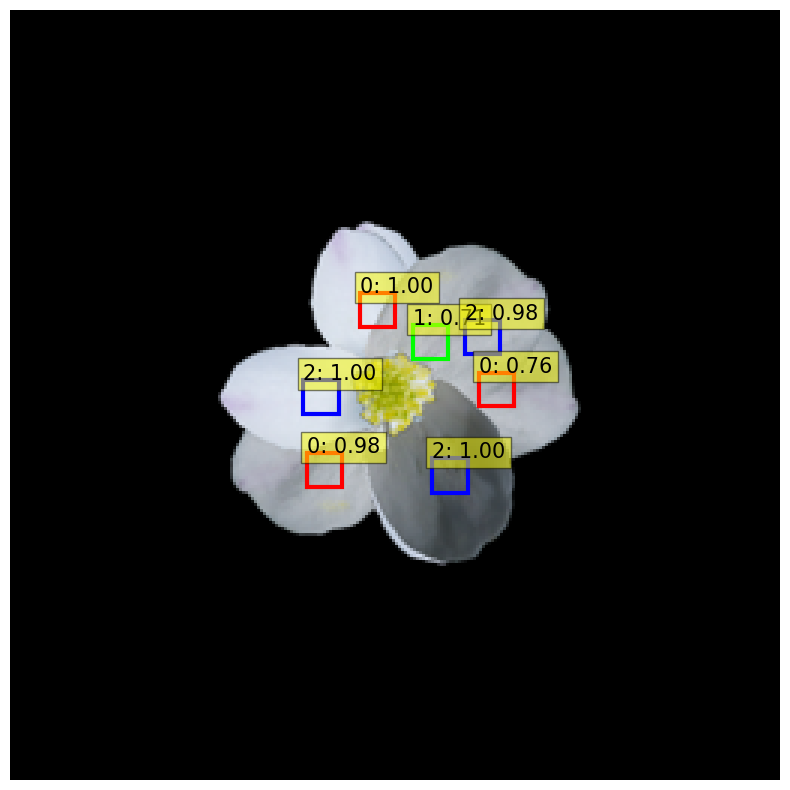

../../create_syntheic_flower_img/data/synthetic_flw/5kind_each10000img/flw/白紫/000001.png
max_fit=5, fit_arrange=('b1', [2, 0, 2, 0, 1]), classes=[2, 0, 1, 2, 0]


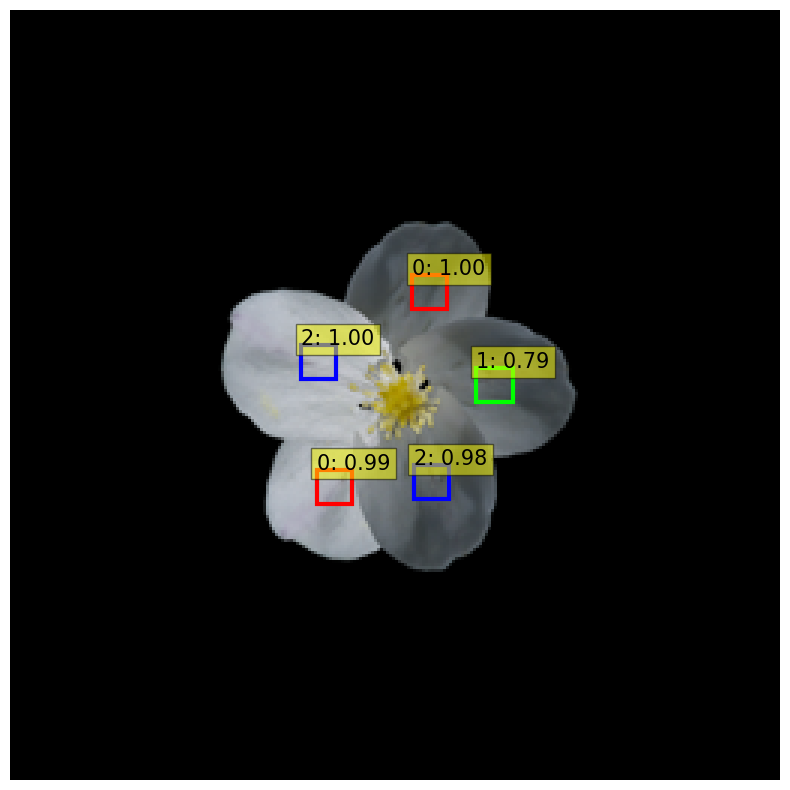

../../create_syntheic_flower_img/data/synthetic_flw/5kind_each10000img/flw/白紫/000002.png
max_fit=5, fit_arrange=('b1', [2, 0, 2, 0, 1]), classes=[0, 1, 2, 0, 2]


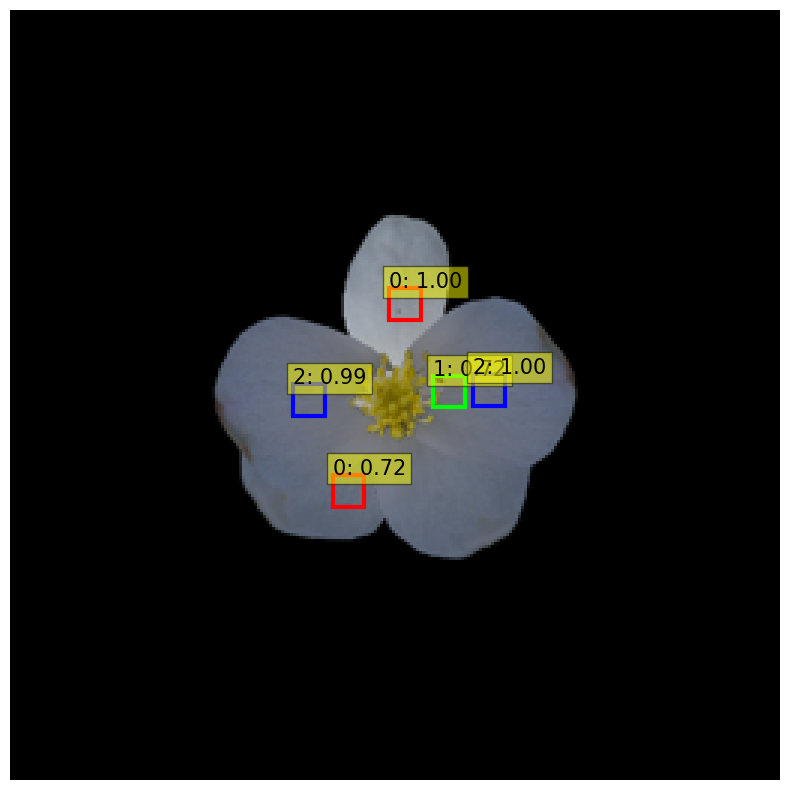

../../create_syntheic_flower_img/data/synthetic_flw/5kind_each10000img/flw/白紫/000003.png
max_fit=4, fit_arrange=('c1', [1, 0, 1, 2, 0, 2]), classes=[2, 0, 1, 1, 2, 0]


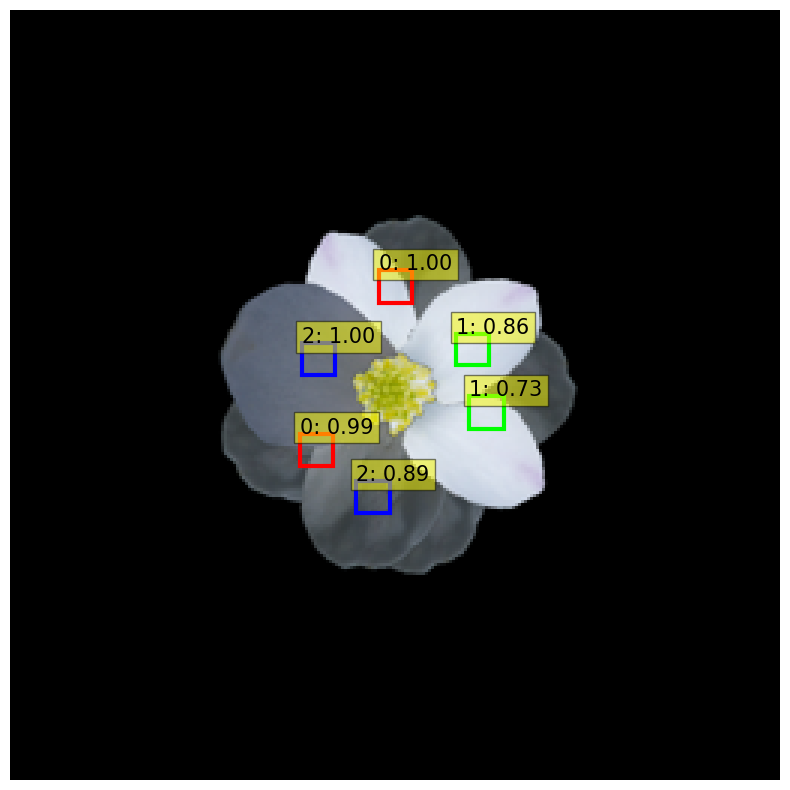

../../create_syntheic_flower_img/data/synthetic_flw/5kind_each10000img/flw/白紫/000004.png
max_fit=4, fit_arrange=('c1', [1, 0, 1, 2, 0, 2]), classes=[2, 0, 2, 2, 0, 2]


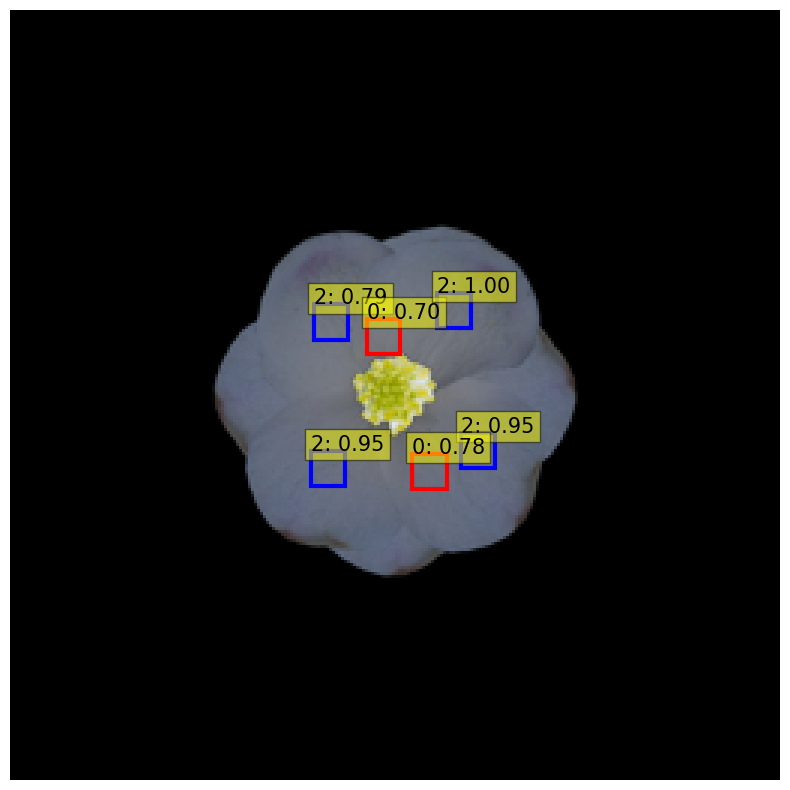

../../create_syntheic_flower_img/data/synthetic_flw/5kind_each10000img/flw/白紫/000005.png
max_fit=4, fit_arrange=('a1', [2, 0, 2, 0]), classes=[0, 2, 0, 2]


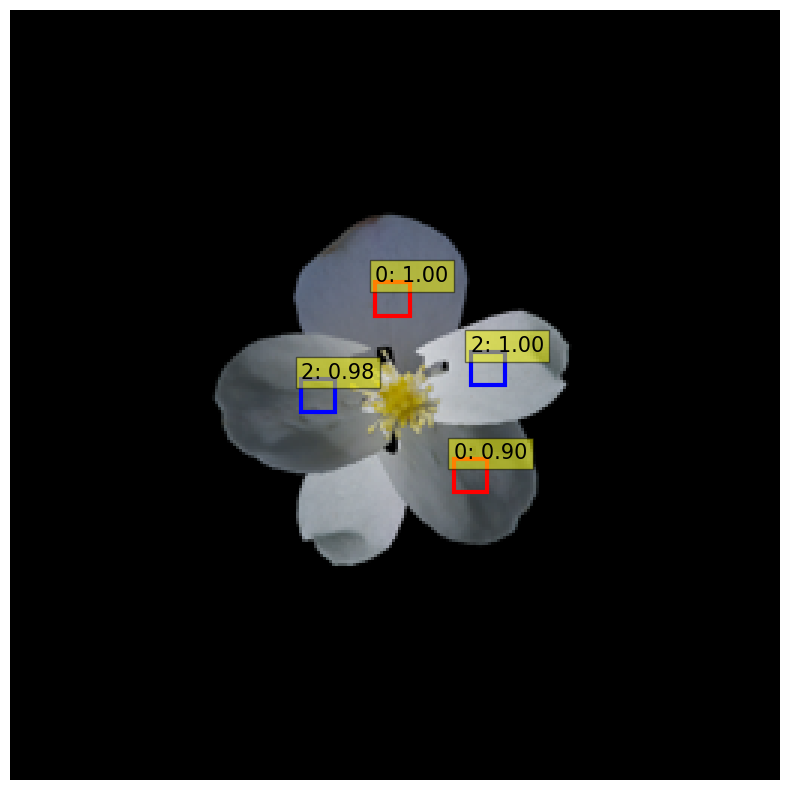

../../create_syntheic_flower_img/data/synthetic_flw/5kind_each10000img/flw/白紫/000006.png
max_fit=7, fit_arrange=('d2', [0, 2, 0, 1, 2, 0, 2]), classes=[2, 0, 2, 0, 2, 0, 1]


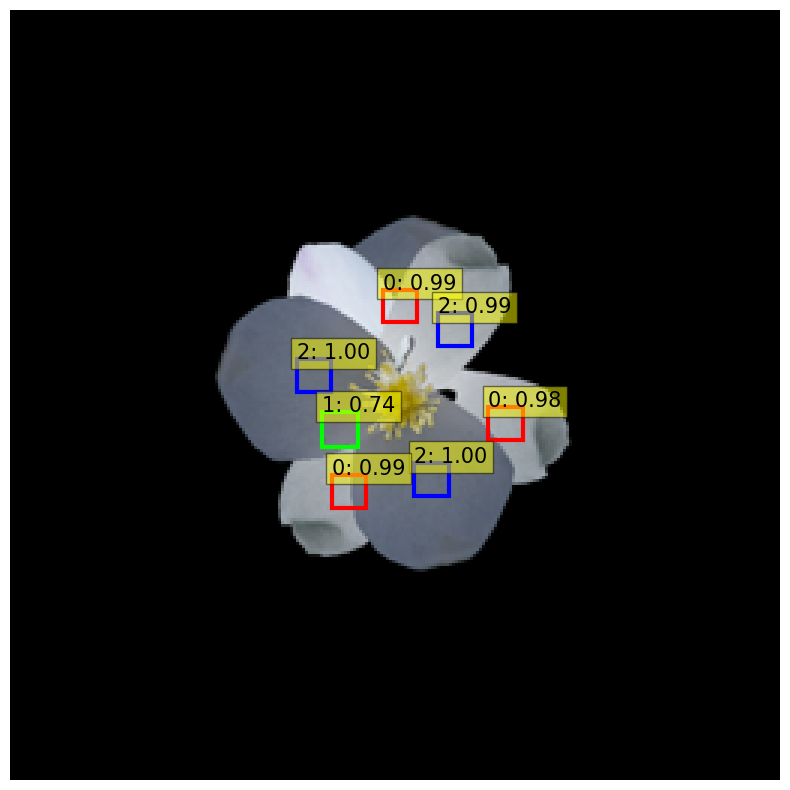

../../create_syntheic_flower_img/data/synthetic_flw/5kind_each10000img/flw/白紫/000007.png
max_fit=6, fit_arrange=('c2', [0, 2, 0, 2, 0, 2]), classes=[0, 2, 0, 2, 0, 2]


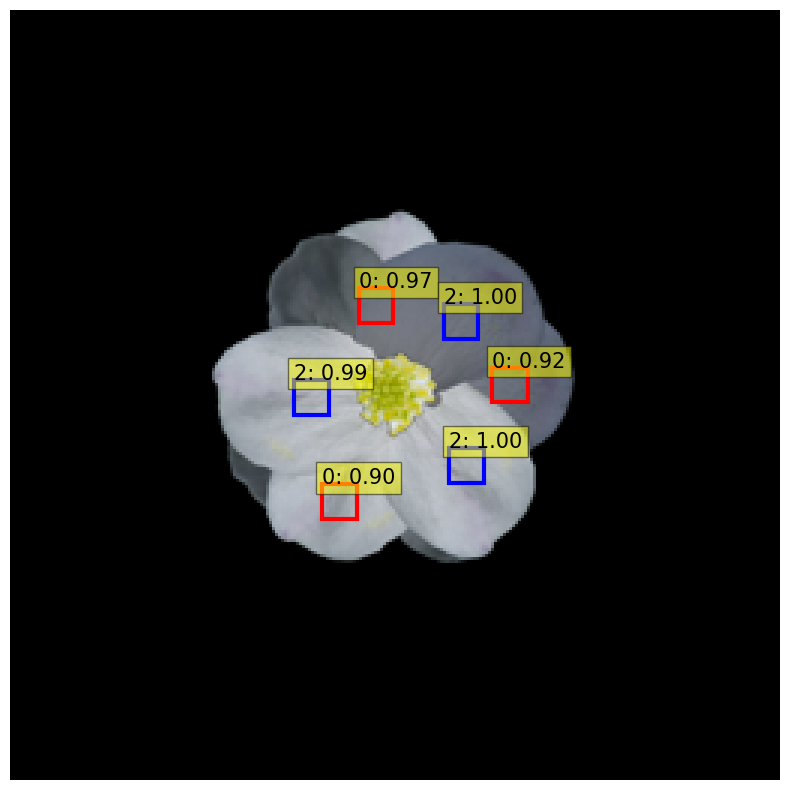

../../create_syntheic_flower_img/data/synthetic_flw/5kind_each10000img/flw/白紫/000008.png
max_fit=0, fit_arrange=[], classes=[2, 0, 2]


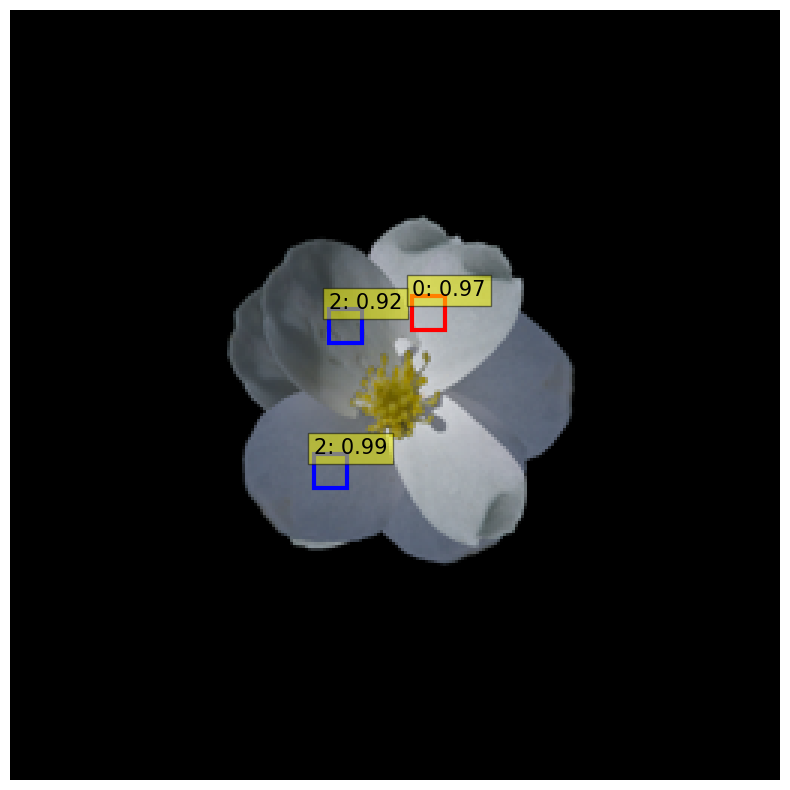

../../create_syntheic_flower_img/data/synthetic_flw/5kind_each10000img/flw/白紫/000009.png
max_fit=5, fit_arrange=('b1', [2, 0, 2, 0, 1]), classes=[2, 0, 1, 2, 0]


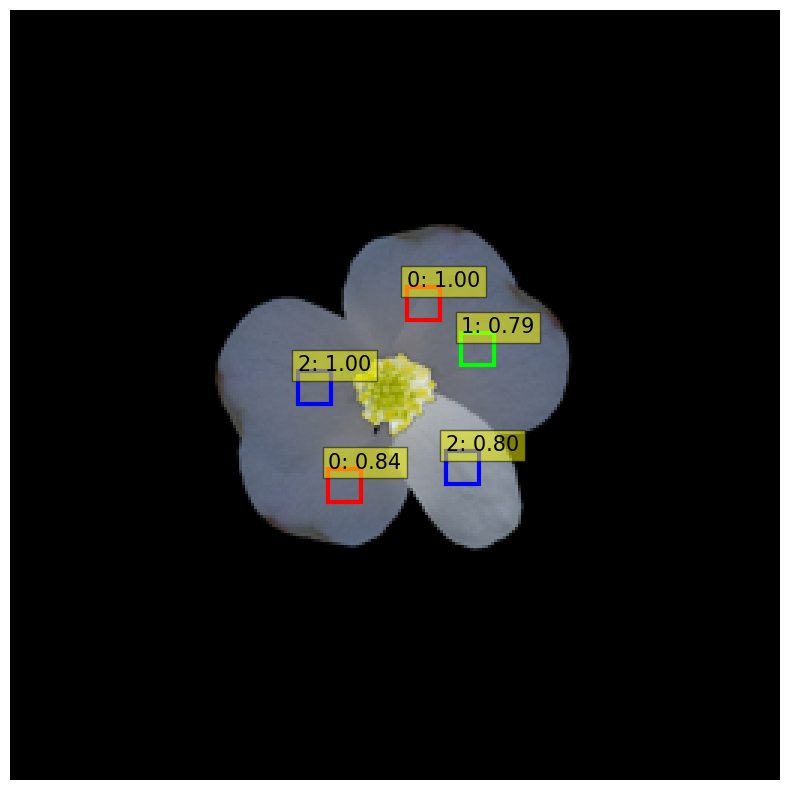

In [8]:
import numpy as np

def init_counters():
    """カウンターの初期化"""
    keys = list(arranges.keys()) + ['others']
    return {
        'arrange_key_counts': {key: 0 for key in keys},
        'arrange_key_counts_ground_truth': {key: 0 for key in keys},
        'key_match_counts': {key: 0 for key in keys},
        'key_mismatch_counts': {key: 0 for key in keys},
        'others_patterns': [],
        'others_patterns_ground_truth': []
    }

def update_counters(counters, max_fit, fit_arrange_key, classes, is_ground_truth=False):
    """カウンターの更新"""
    if max_fit > 0:
        if is_ground_truth:
            counters['arrange_key_counts_ground_truth'][fit_arrange_key] += 1
        else:
            counters['arrange_key_counts'][fit_arrange_key] += 1
    else:
        if is_ground_truth:
            counters['arrange_key_counts_ground_truth']['others'] += 1
            counters['others_patterns_ground_truth'].append(classes)
        else:
            counters['arrange_key_counts']['others'] += 1
            counters['others_patterns'].append(classes)

def update_match_counters(counters, pred_fit, true_fit, pred_key, true_key):
    """マッチングカウンターの更新"""
    if pred_fit > 0 and true_fit > 0:
        if pred_key == true_key:
            counters['key_match_counts'][pred_key] += 1
        else:
            counters['key_mismatch_counts'][pred_key] += 1
            counters['key_mismatch_counts'][true_key] += 1
    elif pred_fit == 0 and true_fit == 0:
        counters['key_match_counts']['others'] += 1
    else:
        if pred_fit == 0:
            counters['key_mismatch_counts']['others'] += 1
            counters['key_mismatch_counts'][true_key] += 1
        else:
            counters['key_mismatch_counts']['others'] += 1
            counters['key_mismatch_counts'][pred_key] += 1

def plot_results_graphs(counters, confusion_matrix):
    """結果のグラフ描画"""
    keys = sorted(list(arranges.keys()) + ['others'], reverse=True)
    plt_settings = {
        'figsize': (16, 10),
        'xlabel': 'Frequency',
        'ylabel': 'Arrangement Pattern'
    }

    # 予測結果のグラフ
    plt.figure(figsize=plt_settings['figsize'])
    plt.barh(keys, [counters['arrange_key_counts'][key] for key in keys])
    plt.title('Predicted Arrangement Pattern Distribution')
    plt.xlabel(plt_settings['xlabel'])
    plt.ylabel(plt_settings['ylabel'])
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

    # 正解データのグラフ
    plt.figure(figsize=plt_settings['figsize'])
    plt.barh(keys, [counters['arrange_key_counts_ground_truth'][key] for key in keys])
    plt.title('Ground Truth Arrangement Pattern Distribution')
    plt.xlabel(plt_settings['xlabel'])
    plt.ylabel(plt_settings['ylabel'])
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

    # Match/Mismatchグラフ
    plt.figure(figsize=plt_settings['figsize'])
    x = np.arange(len(keys))
    width = 0.35

    accuracies = {
        key: (counters['key_match_counts'][key] / (counters['key_match_counts'][key] + counters['key_mismatch_counts'][key]) * 100 
              if (counters['key_match_counts'][key] + counters['key_mismatch_counts'][key]) > 0 else 0)
        for key in keys
    }

    plt.barh(x - width/2, [counters['key_match_counts'][key] for key in keys], width, label='Match')
    plt.barh(x + width/2, [counters['key_mismatch_counts'][key] for key in keys], width, label='Mismatch')

    for i, key in enumerate(keys):
        plt.text(max(counters['key_match_counts'][key], counters['key_mismatch_counts'][key]) + 1, i, 
                f'{accuracies[key]:.1f}%', va='center')

    plt.yticks(x, keys)
    plt.title('Predicted and Ground Truth Key Match/Mismatch Counts')
    plt.xlabel(plt_settings['xlabel'])
    plt.ylabel(plt_settings['ylabel'])
    plt.legend()
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

    # 混同行列のヒートマップ
    heatmap_keys = sorted(list(arranges.keys()) + ['others'])
    plt.figure(figsize=(16, 10))
    plt.imshow(confusion_matrix, cmap='YlOrRd')
    plt.colorbar()

    plt.xticks(np.arange(len(heatmap_keys)), heatmap_keys, rotation=45, ha='right')
    plt.yticks(np.arange(len(heatmap_keys)), heatmap_keys)

    plt.title('Confusion Matrix of Arrangement Patterns')
    plt.xlabel('Ground Truth')
    plt.ylabel('Predicted')

    for i in range(len(heatmap_keys)):
        for j in range(len(heatmap_keys)):
            plt.text(j, i, int(confusion_matrix[i, j]), ha="center", va="center", color="black")

    plt.tight_layout()
    plt.show()

# メイン処理
ENABLE_PRINT = False
ENABLE_PLOT = False

# カウンターの初期化
counters = init_counters()
heatmap_keys = sorted(list(arranges.keys()) + ['others'])
key_to_idx = {key: i for i, key in enumerate(heatmap_keys)}
confusion_matrix = np.zeros((len(heatmap_keys), len(heatmap_keys)))

total_stats = {
    'total_samples': 0,
    'correct_predictions': 0,
    'total_fit_score': 0,
    'total_fit_score_ground_truth': 0
}

all_classes = []
all_sorted_classes = []
all_scores = []

# 結果の処理
for filename, classes, scores, bboxes in results:
    total_stats['total_samples'] += 1
    
    # 予測結果の処理
    max_fit_known, fit_arrange_known, fit_arrange_key_known = calculate_circular_fit_with_arranges(classes)
    total_stats['total_fit_score'] += max_fit_known
    all_classes.append(classes)
    update_counters(counters, max_fit_known, fit_arrange_key_known, classes)

    # 正解データの処理
    annotation_classes, annotation_bboxes = get_ground_truth(filename)
    sorted_bboxes, _, sorted_classes = sort_by_bboxes(annotation_bboxes, [0]*len(annotation_bboxes), annotation_classes)
    all_sorted_classes.append(sorted_classes)
    all_scores.append(scores)

    max_fit_known_ground_truth, fit_arrange_known_ground_truth, fit_arrange_key_known_ground_truth = calculate_circular_fit_with_arranges(sorted_classes)
    total_stats['total_fit_score_ground_truth'] += max_fit_known_ground_truth
    update_counters(counters, max_fit_known_ground_truth, fit_arrange_key_known_ground_truth, sorted_classes, True)

    # 混同行列の更新
    pred_key = fit_arrange_key_known if max_fit_known > 0 else 'others'
    true_key = fit_arrange_key_known_ground_truth if max_fit_known_ground_truth > 0 else 'others'
    confusion_matrix[key_to_idx[pred_key]][key_to_idx[true_key]] += 1

    # 正解判定
    if pred_key == true_key:
        total_stats['correct_predictions'] += 1

    # マッチングカウンターの更新
    update_match_counters(counters, max_fit_known, max_fit_known_ground_truth, 
                         fit_arrange_key_known, fit_arrange_key_known_ground_truth)

# 精度評価指標の計算と出力
print("\n=== 精度評価指標 ===")
print(f"総サンプル数: {total_stats['total_samples']}")
print(f"正解数: {total_stats['correct_predictions']}")
print(f"正解率: {(total_stats['correct_predictions'] / total_stats['total_samples']) * 100:.2f}%")
# print(f"平均適合度スコア(予測): {total_stats['total_fit_score'] / total_stats['total_samples']:.2f}")
# print(f"平均適合度スコア(正解): {total_stats['total_fit_score_ground_truth'] / total_stats['total_samples']:.2f}")

# パターンごとの精度
print("\n=== パターンごとの精度 ===")
for key in arranges.keys():
    total = counters['key_match_counts'][key] + counters['key_mismatch_counts'][key]
    if total > 0:
        accuracy = (counters['key_match_counts'][key] / total) * 100
        print(f"{key}: {accuracy:.2f}% ({counters['key_match_counts'][key]}/{total})")

# 混同行列の表示
print("\n=== 混同行列 ===")
print("予測＼正解", end="\t")
for key in heatmap_keys:
    print(f"{key[:4]}", end="\t")
print()
for i, pred_key in enumerate(heatmap_keys):
    print(f"{pred_key[:4]}", end="\t")
    for j in range(len(heatmap_keys)):
        print(f"{int(confusion_matrix[i][j])}", end="\t")
    print()

# othersのパターンを表示
print("\n=== othersのパターン(上位10個) ===")
print("\n予測結果のothersパターン:")
for pattern in counters['others_patterns'][:10]:
    print(pattern)

print("\n正解データのothersパターン:")
for pattern in counters['others_patterns_ground_truth'][:10]:
    print(pattern)

# グラフの描画
plot_results_graphs(counters, confusion_matrix)

# 予測結果の可視化
if ENABLE_PLOT:
    for i in range(10):
        plot_results(Image.open(results[i][0]), all_classes[i], all_scores[i], results[i][3])

In [ ]:
# フォルダごとに結果を分割 (1フォルダあたり10000サンプル)
SAMPLES_PER_FOLDER = 10000
each_folder_results = [
    results[i:i + SAMPLES_PER_FOLDER] 
    for i in range(0, len(results), SAMPLES_PER_FOLDER)
]

# フォルダ名を取得
folder_names = []
for filename, _, _, _ in results:
    folder_name = filename.split('/')[-2]  # パスからフォルダ名を抽出
    if folder_name not in folder_names:
        folder_names.append(folder_name)

print("フォルダ名一覧:")
for name in folder_names:
    print(name)

# 全フォルダの結果を格納する辞書
folder_stats = {}

# フォルダごとに結果を処理
for folder_idx, (folder_name, folder_results) in enumerate(zip(folder_names, each_folder_results)):
    folder_stats[folder_name] = {
        'total_stats': {
            'total_samples': 0,
            'correct_predictions': 0,
            'total_fit_score': 0,
            'total_fit_score_ground_truth': 0
        },
        'pattern_stats': {},
        'confusion_matrix': None,
        'others_patterns': [],
        'others_patterns_ground_truth': []
    }

    # カウンターの初期化
    counters = init_counters()
    heatmap_keys = sorted(list(arranges.keys()) + ['others'])
    key_to_idx = {key: i for i, key in enumerate(heatmap_keys)}
    confusion_matrix = np.zeros((len(heatmap_keys), len(heatmap_keys)))

    all_classes = []
    all_sorted_classes = []
    all_scores = []

    # 結果の処理
    for filename, classes, scores, bboxes in folder_results:
        folder_stats[folder_name]['total_stats']['total_samples'] += 1
        
        # 予測結果の処理
        max_fit_known, fit_arrange_known, fit_arrange_key_known = calculate_circular_fit_with_arranges(classes)
        folder_stats[folder_name]['total_stats']['total_fit_score'] += max_fit_known
        all_classes.append(classes)
        update_counters(counters, max_fit_known, fit_arrange_key_known, classes)

        # 正解データの処理
        annotation_classes, annotation_bboxes = get_ground_truth(filename)
        sorted_bboxes, _, sorted_classes = sort_by_bboxes(annotation_bboxes, [0]*len(annotation_bboxes), annotation_classes)
        all_sorted_classes.append(sorted_classes)
        all_scores.append(scores)

        max_fit_known_ground_truth, fit_arrange_known_ground_truth, fit_arrange_key_known_ground_truth = calculate_circular_fit_with_arranges(sorted_classes)
        folder_stats[folder_name]['total_stats']['total_fit_score_ground_truth'] += max_fit_known_ground_truth
        update_counters(counters, max_fit_known_ground_truth, fit_arrange_key_known_ground_truth, sorted_classes, True)

        # 混同行列の更新
        pred_key = fit_arrange_key_known if max_fit_known > 0 else 'others'
        true_key = fit_arrange_key_known_ground_truth if max_fit_known_ground_truth > 0 else 'others'
        confusion_matrix[key_to_idx[pred_key]][key_to_idx[true_key]] += 1

        # 正解判定
        if pred_key == true_key:
            folder_stats[folder_name]['total_stats']['correct_predictions'] += 1

        # マッチングカウンターの更新
        update_match_counters(counters, max_fit_known, max_fit_known_ground_truth, 
                            fit_arrange_key_known, fit_arrange_key_known_ground_truth)

    # フォルダごとの統計情報を保存
    folder_stats[folder_name]['pattern_stats'] = {
        key: {
            'matches': counters['key_match_counts'][key],
            'mismatches': counters['key_mismatch_counts'][key]
        } for key in arranges.keys()
    }
    folder_stats[folder_name]['confusion_matrix'] = confusion_matrix
    folder_stats[folder_name]['others_patterns'] = counters['others_patterns'][:10]
    folder_stats[folder_name]['others_patterns_ground_truth'] = counters['others_patterns_ground_truth'][:10]

# 結果の比較表示
print("\n=== フォルダ間の比較 ===")

# 1. 基本精度の比較
print("\n[1] 基本精度の比較")
print("フォルダ\t総サンプル数\t正解数\t正解率")
for folder_name, stats in folder_stats.items():
    total = stats['total_stats']['total_samples']
    correct = stats['total_stats']['correct_predictions']
    accuracy = (correct / total) * 100
    print(f"{folder_name}\t{total}\t{correct}\t{accuracy:.2f}%")

# 2. 適合度スコアの比較
print("\n[2] 適合度スコアの比較")
print("フォルダ\t予測平均\t正解平均")
for folder_name, stats in folder_stats.items():
    total = stats['total_stats']['total_samples']
    pred_avg = stats['total_stats']['total_fit_score'] / total
    true_avg = stats['total_stats']['total_fit_score_ground_truth'] / total
    print(f"{folder_name}\t{pred_avg:.2f}\t{true_avg:.2f}")

# 3. パターンごとの精度比較
print("\n[3] パターンごとの精度比較")
print("フォルダ", end="\t")
for key in arranges.keys():
    print(f"{key[:4]}", end="\t")
print()

for folder_name, stats in folder_stats.items():
    print(f"{folder_name}", end="\t")
    for key in arranges.keys():
        matches = stats['pattern_stats'][key]['matches']
        total = matches + stats['pattern_stats'][key]['mismatches']
        accuracy = (matches / total) * 100 if total > 0 else 0
        print(f"{accuracy:.1f}%", end="\t")
    print()

# 4. フォルダごとの詳細な結果表示と視覚化
for folder_name, stats in folder_stats.items():
    print(f"\n=== {folder_name} の詳細結果 ===")
    total = stats['total_stats']['total_samples']
    
    # 混同行列の表示
    print("\n混同行列:")
    print("予測＼正解", end="\t")
    for key in heatmap_keys:
        print(f"{key[:4]}", end="\t")
    print()
    
    confusion_matrix = stats['confusion_matrix']
    for i, pred_key in enumerate(heatmap_keys):
        print(f"{pred_key[:4]}", end="\t")
        for j in range(len(heatmap_keys)):
            print(f"{int(confusion_matrix[i][j])}", end="\t")
        print()

    # その他パターンの表示
    print("\nその他パターン (上位5件):")
    print("予測:", stats['others_patterns'][:5])
    print("正解:", stats['others_patterns_ground_truth'][:5])
    
    # グラフの描画
    plot_results_graphs(counters, confusion_matrix)

In [3]:
arranges = {
    'a1':[2,0,2,0],
    'a2':[1,2,1,0],
    'a3':[1,1,2,0],
    'b1':[1,0,2,0,2],
    'c1':[1,0,1,2,0,2],
    'c2':[0,2,0,2,0,2],
    'c3':[2,1,0,2,0,1],
    'd1':[2,1,0,2,1,0,1],
    'd2':[0,2,0,1,2,0,2],
    'e1':[2,1,0,1,2,0,2,0],
    'e2':[0,2,0,2,0,2,0,2],
    'e3':[0,2,0,2,1,0,2,1],
    'f1':[0,2,0,2,0,2,0,1,2],
    'g1':[2,0,2,0,2,0,2,0,2,0]
}

import numpy as np

class Levenshtein:
    def __init__(self, array1, array2):
        self.array1 = array1
        self.array2 = array2
        self.len1 = len(array1) + 1
        self.len2 = len(array2) + 1
        self.calcurated = False
        self.saving_memory = True

    # 計算用Arrayの初期化
    def init_array(self):
        arr = np.zeros((self.len1, self.len2), dtype=int)
        for i in range(self.len1):
            arr[i, 0] = i
        for i in range(self.len2):
            arr[0, i] = i
        self.array = arr
    
    # 文字列の比較
    def is_same(self, i, j):
        if self.array1[i - 1] is self.array2[j - 1]:
            return True
        else:
            return False

    # フルのArrayで距離計算
    def calcurate_full_array(self):
        self.init_array() #フルArrayの初期化
        arr = self.array
        for i in range(1, self.len1):
            for j in range(1, self.len2):
                naname = arr[i-1, j-1] # 左上の値
                if not self.is_same(i, j): # 文字が一致しなければ、+1
                    naname += 1
                # 左、左上、上の3つの中で最も小さいもの
                mini = np.min([naname, arr[i-1, j] + 1, arr[i, j-1] + 1])
                arr[i, j] = mini
        # Arrayの右下が求める距離
        self.distance = arr[self.len1 - 1, self.len2 - 1]

    # Arrayを節約
    def calcurate_saving_memory(self):
        # 文字列の長さに応じて、交換
        if self.len1 < self.len2:
            tmp = self.array1
            self.array1 = self.array2
            self.array2 = tmp
            tmp = self.len1
            self.len1 = self.len2
            self.len2 = tmp
        # Init arrays
        arr1 = np.zeros((self.len2), dtype=int)
        arr2 = np.zeros((self.len2), dtype=int)
        for i in range(self.len2):
            arr1[i] = i

        for i in range(1, self.len1):
            arr2[0] = i
            for j in range(1, self.len2):
                naname = arr1[j-1]
                if not self.is_same(i, j):
                    naname += 1
                mini = np.min([naname, arr1[j] + 1, arr2[j-1] + 1])
                arr2[j] = mini
            arr1 = arr2.copy()
        self.distance = arr2[self.len2 - 1]

    def calcurate(self, saving_memory=True):
        if saving_memory:
            self.calcurate_saving_memory()
        else:
            self.calcurate_full_array()
            self.saving_memory = False
        self.calcurated = True

    def print_array(self): 
        if self.calcurated and  (not self.saving_memory):
            list_print = []
            line = [' ', ' ']
            line.extend([s for s in self.array2])
            list_print.append(line)
            tmp = [' ']
            tmp.extend(self.array1)
            for i, s in enumerate(tmp):
                line = [s]
                line.extend(self.array[i,:].astype(str).tolist())
                list_print.append(line)
            for l in list_print:
                print(l)
        else:
            print('Array is NOT exist. Use calcurate(saving_memory=False).')

class Cyclic_Levenshtein:
    def __init__(self):
        self.cache = {}

    def reverse_order(self,arr):
        return arr[::-1]

    def calculate_circular_fit(self, seq1, seq2):
        # 円順列のすべての回転を生成
        n = len(seq1)
        rotations = [seq1[i:] + seq1[:i] for i in range(n)]
    
        # 各回転について編集距離を計算し、最小距離を探索
        min_distance = float('inf')
        for rotation in rotations:
            leven = Levenshtein(rotation, seq2)
            leven.calcurate()
            distance = leven.distance
            if distance < min_distance:
                min_distance = distance
    
        return min_distance
    
    def calculate_circular_fit_with_arrange(self, cycle1, cycle2, isLog=False):
        cache_key = (tuple(cycle1), tuple(cycle2))
        if cache_key in self.cache:
            return self.cache[cache_key]
        
        distance = self.calculate_circular_fit(cycle1, cycle2)
        reverse_distance = self.calculate_circular_fit(cycle1, self.reverse_order(cycle2))
        if distance > reverse_distance:
            distance = reverse_distance
            cycle2 = self.reverse_order(cycle2)
        
        self.cache[cache_key] = (distance, cycle2)
        return distance, cycle2
    
    def calculate_circular_fit_with_arranges(self, cycle1, petalCount, isLog=False):
        max_distance = float('inf')
        fit_arrange = []
        fit_arrange_key = ''
        for key, arrange_list in arranges.items():
            if (petalCount is not None) & (petalCount != len(arrange_list)):
                continue
            distance, arrange = self.calculate_circular_fit_with_arrange(cycle1, arrange_list, isLog)
            if max_distance >= distance:
                max_distance = distance
                fit_arrange = arrange
                fit_arrange_key = key
        
        return max_distance, fit_arrange, fit_arrange_key

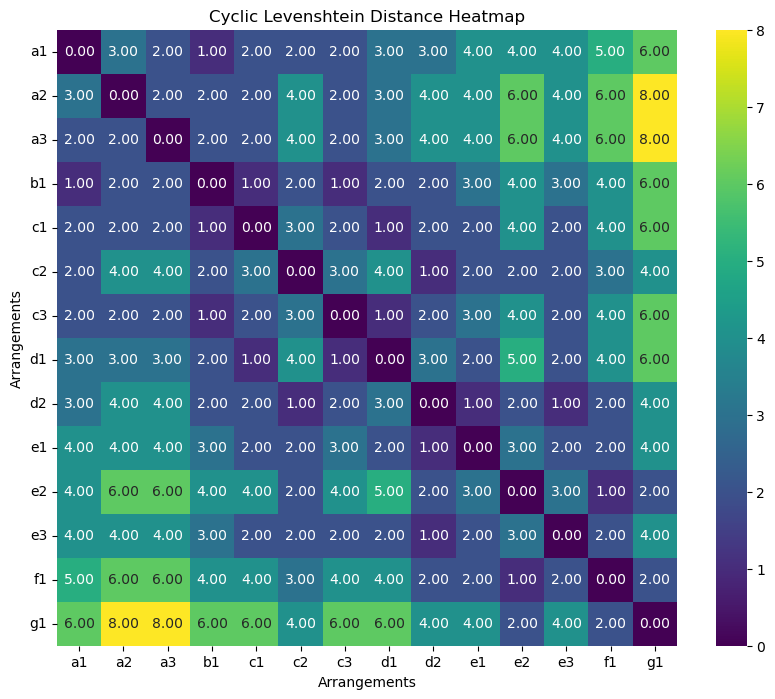

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cyclic_levenshtein = Cyclic_Levenshtein()

# 全ての組み合わせについて円順列編集距離を計算
distance_matrix = np.zeros((len(arranges), len(arranges)))
keys = list(arranges.keys())

for i, key1 in enumerate(keys):
    for j, key2 in enumerate(keys):
        if key1 != key2:  # 同じキーの組み合わせは除外
            distance, _ = cyclic_levenshtein.calculate_circular_fit_with_arrange(arranges[key1], arranges[key2])
            distance_matrix[i, j] = distance

# ヒートマップを可視化
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, xticklabels=keys, yticklabels=keys, cmap='viridis', annot=True, fmt=".2f", cbar_kws={"orientation": "vertical"})
plt.title('Cyclic Levenshtein Distance Heatmap')
plt.xlabel('Arrangements')
plt.ylabel('Arrangements')
plt.yticks(rotation=0)  # 縦軸のラベルを回転

# ヒートマップを保存
plt.savefig('cyclic_levenshtein_distance_heatmap.png', bbox_inches='tight')
plt.show()


In [ ]:
import os


# メイン処理
ENABLE_PRINT = False
ENABLE_PLOT = False

# カウンターの初期化
counters = init_counters()
heatmap_keys = sorted(list(arranges.keys()) + ['others'])
key_to_idx = {key: i for i, key in enumerate(heatmap_keys)}
confusion_matrix = np.zeros((len(heatmap_keys), len(heatmap_keys)))

total_stats = {
    'total_samples': 0,
    'correct_predictions': 0,
    'total_fit_score': 0,
    'total_fit_score_ground_truth': 0,
    'correct_petal_counts': 0,
}

all_classes = []
all_sorted_classes = []
all_scores = []

filtered_results = results

# 結果の処理
for filename, classes, scores, bboxes in filtered_results:
    total_stats['total_samples'] += 1

    # 正解データの処理
    annotation_classes, annotation_bboxes = get_ground_truth(filename)
    sorted_bboxes, _, sorted_classes = sort_by_bboxes(annotation_bboxes, [0]*len(annotation_bboxes), annotation_classes)
    all_sorted_classes.append(sorted_classes)
    all_scores.append(scores)

    max_fit_known_ground_truth, fit_arrange_known_ground_truth, fit_arrange_key_known_ground_truth = cyclic_leven.calculate_circular_fit_with_arranges(sorted_classes, len(sorted_classes))
    total_stats['total_fit_score_ground_truth'] += max_fit_known_ground_truth
    update_counters(counters, max_fit_known_ground_truth, fit_arrange_key_known_ground_truth, sorted_classes, True)
    
    # 予測結果の処理
    max_fit_known, fit_arrange_known, fit_arrange_key_known = cyclic_leven.calculate_circular_fit_with_arranges(classes, None, isLog = True)
    total_stats['total_fit_score'] += max_fit_known
    all_classes.append(classes)
    update_counters(counters, max_fit_known, fit_arrange_key_known, classes)
    
    # 花弁の枚数の正誤
    if (abs(len(classes) - len(sorted_classes))==0):
        total_stats['correct_petal_counts'] +=1

    # 混同行列の更新
    pred_key = fit_arrange_key_known
    true_key = fit_arrange_key_known_ground_truth
    confusion_matrix[key_to_idx[pred_key]][key_to_idx[true_key]] += 1

    # 正解判定
    if pred_key == true_key:
        total_stats['correct_predictions'] += 1
    else:
        # 予測と正解が異なる場合、画像を保存
        img = Image.open(filename)        
        # Create the directory if it doesn't exist
        os.makedirs(f"incorrect_predictions/{true_key}", exist_ok=True)
        
        # Draw bounding boxes on the image
        draw = ImageDraw.Draw(img)
        # Draw the ground truth bounding boxes
        for bbox in annotation_bboxes:
            draw.rectangle(bbox, outline="green", width=2)  # Green for ground truth
        # Draw the predicted bounding boxes
        for bbox in bboxes:
            draw.rectangle(bbox, outline="red", width=2)  # Red for predictions
        
        img.save(f"incorrect_predictions/{true_key}/{pred_key}_vs_{true_key}_{total_stats['total_samples']}.png")

    # マッチングカウンターの更新
    update_match_counters(counters, max_fit_known, max_fit_known_ground_truth, 
                         fit_arrange_key_known, fit_arrange_key_known_ground_truth)

    if ENABLE_PLOT:
        img = Image.open(filename)
        img = img.resize((256, 256))  # 前処理のサイズに変形
        plot_results(img, classes, scores, bboxes)

# 精度評価指標の計算と出力
print("\n=== 精度評価指標 ===")
print(f"総サンプル数: {total_stats['total_samples']}")
print(f"正解数: {total_stats['correct_predictions']}")
print(f"正解率: {(total_stats['correct_predictions'] / total_stats['total_samples']) * 100:.2f}%")
print(f"正解数（花弁の枚数）: {total_stats['correct_petal_counts']}")
print(f"正解率（花弁の枚数）: {(total_stats['correct_petal_counts'] / total_stats['total_samples']) * 100:.2f}%")
print(f"平均適合度スコア(予測): {total_stats['total_fit_score'] / total_stats['total_samples']:.2f}")
print(f"平均適合度スコア(正解): {total_stats['total_fit_score_ground_truth'] / total_stats['total_samples']:.2f}")

# パターンごとの精度
print("\n=== パターンごとの精度 ===")
for key in arranges.keys():
    total = counters['key_match_counts'][key] + counters['key_mismatch_counts'][key]
    if total > 0:
        accuracy = (counters['key_match_counts'][key] / total) * 100
        print(f"{key}: {accuracy:.2f}% ({counters['key_match_counts'][key]}/{total})")
    else:
        print(f"{key}: 該当データなし")

# 混同行列の表示
print("\n=== 混同行列 ===")
print("予測＼正解", end="\t")
for key in heatmap_keys:
    print(f"{key[:4]}", end="\t")
print()
for i, pred_key in enumerate(heatmap_keys):
    print(f"{pred_key[:4]}", end="\t")
    for j in range(len(heatmap_keys)):
        print(f"{int(confusion_matrix[i][j])}", end="\t")
    print()

# othersのパターンを表示
print("\n=== othersのパターン(上位10個) ===")
print("\n予測結果のothersパターン:")
for pattern in counters['others_patterns'][:10]:
    print(pattern)

print("\n正解データのothersパターン:")
for pattern in counters['others_patterns_ground_truth'][:10]:
    print(pattern)

# グラフの描画
plot_results_graphs(counters, confusion_matrix)

In [ ]:
for label, box in zip(target['labels'], target['boxes']):
    label = label.item()
    labeled_bbox = (box * 256).tolist()
    draw.text([labeled_bbox[0] - petal_size // 2 + text_left_padding, labeled_bbox[1] - petal_size // 2], str(label), '#FFFFFF')
    # draw.rectangle([tuple(labeled_bbox[:2]), (labeled_bbox[0] + 20,labeled_bbox[1]+20)], outline=(255, 255, 255), width=1)
    draw.rectangle([(labeled_bbox[0]- petal_size // 2, labeled_bbox[1]- petal_size // 2), (labeled_bbox[0] + petal_size // 2,labeled_bbox[1] + petal_size // 2)], outline=(255, 255, 255), width=1)

In [ ]:

def plot_results(pil_img, classes, scores, boxes, true_classes, true_boxes, image_path):
    plt.figure(figsize=(16,10))
    plt.imshow(pil_img)
    ax = plt.gca()
    # for cl, score, (xmin, ymin, xmax, ymax) in zip(classes, scores, boxes):
    #     ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
    #                                fill=False, color=COLORS[cl][1], linewidth=3))
    #     text = f'{CLASSES[cl]}: {score:0.2f}'
    #     ax.text(xmin, ymin, text, fontsize=15,
    #             bbox=dict(facecolor='yellow', alpha=0.5))

    # Visualize true boxes
    for true_cl, (true_ycenter, true_xcenter, true_xwidth, true_ywidth) in zip(true_classes, true_boxes):
        true_xmin = true_xcenter - true_xwidth // 2
        true_ymin = true_ycenter - true_ywidth // 2
        ax.add_patch(plt.Rectangle((true_xmin, true_ymin), true_xwidth, true_ywidth,
                                   fill=False, color='white', linewidth=2, linestyle='--'))
        true_text = CLASSES[true_cl]
        ax.text(true_xcenter, true_ycenter, true_text, fontsize=12, color='white')
    
    plt.axis('off')
    if image_path:
        plt.savefig(image_path)  # Save the figure as an image
    else:
        plt.show()
    plt.close()  # Close the figure to free up memory

In [ ]:
import torchvision
from PIL import Image, ImageDraw, ImageFont
import cv2
import os

petal_size = 10
text_left_padding = 3

# 8つの画像を保持するためのリスト
images = []

font_path = os.path.join(cv2.__path__[0],'qt','fonts','DejaVuSans.ttf')
font = ImageFont.truetype(font_path, size = 14)


In [22]:
class MetricsCalculator:
    def __init__(self):
        self.true_positives = 0
        self.false_positives = 0
        self.false_negatives = 0

    def update(self, true_boxes, true_labels, pred_boxes, pred_labels):
        matched_pred_indices = set()  # To keep track of matched predictions

        for true_box, true_label in zip(true_boxes, true_labels):
            matched = False
            for i, (pred_box, pred_label) in enumerate(zip(pred_boxes, pred_labels)):
                if self.iou(true_box, pred_box) >= 0.5 and true_label == pred_label:
                    self.true_positives += 1
                    matched_pred_indices.add(i)
                    matched = True
                    break
            if not matched:
                self.false_negatives += 1

        self.false_positives += len(pred_boxes) - len(matched_pred_indices)

    def iou(self, a, b):
        ax_mn, ay_mn, ax_mx, ay_mx = a[0], a[1], a[2], a[3]
        bx_mn, by_mn, bx_mx, by_mx = b[0], b[1], b[2], b[3]

        a_area = (ax_mx - ax_mn + 1) * (ay_mx - ay_mn + 1)
        b_area = (bx_mx - bx_mn + 1) * (by_mx - by_mn + 1)

        abx_mn = max(ax_mn, bx_mn)
        aby_mn = max(ay_mn, by_mn)
        abx_mx = min(ax_mx, bx_mx)
        aby_mx = min(ay_mx, by_mx)
        w = max(0, abx_mx - abx_mn + 1)
        h = max(0, aby_mx - aby_mn + 1)
        intersect = w * h

        return intersect / (a_area + b_area - intersect) if (a_area + b_area - intersect) > 0 else 0

class MetricsAggregator:
    def __init__(self):
        self.total_true_positives = 0
        self.total_false_positives = 0
        self.total_false_negatives = 0
        self.count = 0

    def update(self, metrics_calculator):
        self.total_true_positives += metrics_calculator.true_positives
        self.total_false_positives += metrics_calculator.false_positives
        self.total_false_negatives += metrics_calculator.false_negatives
        self.count += 1

    def precision(self):
        return self.total_true_positives / (self.total_true_positives + self.total_false_positives) if (self.total_true_positives + self.total_false_positives) > 0 else 0

    def recall(self):
        return self.total_true_positives / (self.total_true_positives + self.total_false_negatives) if (self.total_true_positives + self.total_false_negatives) > 0 else 0

    def accuracy(self):
        total_boxes = self.total_true_positives + self.total_false_positives + self.total_false_negatives
        return self.total_true_positives / total_boxes if total_boxes > 0 else 0

    def f1_score(self):
        p = self.precision()
        r = self.recall()
        return 2 * (p * r) / (p + r) if (p + r) > 0 else 0

    def print_results(self):
        print("Total True Positives:", self.total_true_positives)
        print("Total False Positives:", self.total_false_positives)
        print("Total False Negatives:", self.total_false_negatives)
        print("Total Precision:", self.precision())
        print("Total Recall:", self.recall())
        print("Total F1 Score:", self.f1_score())
        print("Total Accuracy:", self.accuracy(self.total_true_positives + self.total_false_positives + self.total_false_negatives))

# 使用例
if __name__ == "__main__":
    # 複数の真のバウンディングボックスと予測されたバウンディングボックスの例
    true_boxes_list = [
        [[50, 50, 100, 100], [150, 150, 200, 200]],
        [[30, 30, 80, 80], [120, 120, 180, 180]],
        [[10, 10, 40, 40], [200, 200, 250, 250]]
    ]
    true_labels_list = [
        [0, 1],
        [1, 2],
        [0, 1]
    ]
    pred_boxes_list = [
        [[55, 55, 95, 95], [160, 160, 210, 210], [300, 300, 350, 350]],
        [[35, 35, 75, 75], [125, 125, 185, 185], [220, 220, 270, 270]],
        [[15, 15, 35, 35], [205, 205, 255, 255]]
    ]
    pred_labels_list = [
        [0, 1, 2],
        [1, 2, 0],
        [0, 1]
    ]

    metrics_aggregator = MetricsAggregator()

    for true_boxes, true_labels, pred_boxes, pred_labels in zip(true_boxes_list, true_labels_list, pred_boxes_list, pred_labels_list):
        metrics_calculator = MetricsCalculator()
        metrics_calculator.update(true_boxes, true_labels, pred_boxes, pred_labels)
        metrics_aggregator.update(metrics_calculator)

    metrics_aggregator.print_results()


Total True Positives: 4
Total False Positives: 4
Total False Negatives: 2
Total Precision: 0.5
Total Recall: 0.6666666666666666
Total F1 Score: 0.5714285714285715
Total Accuracy: 0.4


In [ ]:
# for output bounding box post-processing
def box_cxcywh_to_xyxy(bboxes):
    converted_bboxes = []
    for x in bboxes:
        y_c, x_c, w, h = x[0], x[1], x[2], x[3]  # Access elements directly from the list
        b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
             (x_c + 0.5 * w), (y_c + 0.5 * h)]
        converted_bboxes.append(torch.tensor(b))  # Use torch.tensor instead of torch.stack
    return torch.stack(converted_bboxes)  # Use torch.stack to concatenate the list of tensors
